In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo
import matplotlib.dates as mdates
from scipy.integrate import cumulative_trapezoid #, trapz

############################## OPEN MODEL DATA ##############################
ds = xr.open_dataset("flocmod_39.nc", decode_times=False)
volume = 4/3 * np.pi * (ds.Ds/2)**3 

date = pd.to_datetime("2020-07-16 20:10:01")
ds = ds.dropna(dim="N", how="any")
mtime = [date + pd.Timedelta(t, unit='s') for t in ds.time.values]
nt = len(ds.time) 
Nens = len(ds.N)
Ns = len(ds.Ds)
############################## OPEN ADCP DATA ##############################
adcp = xr.open_dataset("/global/scratch/users/siennaw/data/usgs/resampled_adcp_usgs.nc") #, decode_times=False)
rtime = adcp.time.values #[low:high]
offset= 3.537306921274909
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]
adcp_u = np.squeeze(adcp.u_1205)
adcp_z = adcp.depth.values
print(adcp.lon.values, adcp.lat.values)

############################## DEFINE SUPPORTING FUNCTIONS #############################
def julian_to_datetime(julian_days, seconds_, base_julian=2440000, base_date_str="1968-05-23 00:00:00"):
    # 1. Establish your datum anchor point

    julian_days = np.asarray(julian_days)
    seconds_ = np.asarray(seconds_)
    base_date = np.datetime64(base_date_str)
    days_diff = (julian_days - base_julian) * np.timedelta64(1, 'D')
    seconds = seconds_ * np.timedelta64(1, 'ms')
    dates = base_date + days_diff + seconds
    return dates

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

############################## OPEN LISST DATA ##############################
fn = "/global/scratch/users/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SC104ls-b.nc"
lds = xr.open_dataset(fn, decode_times=False)
ldates = julian_to_datetime(lds['time'].values, lds['time2'].values)
lds = lds.assign_coords(time=ldates)

/global/home/users/siennaw/.conda/envs/geoplot/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


[-122.16842] [37.54722]


/tmp/ipykernel_192611/1684722119.py:49: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  lds = lds.assign_coords(time=ldates)


Text(0.5, 0, 'Time [hr]')

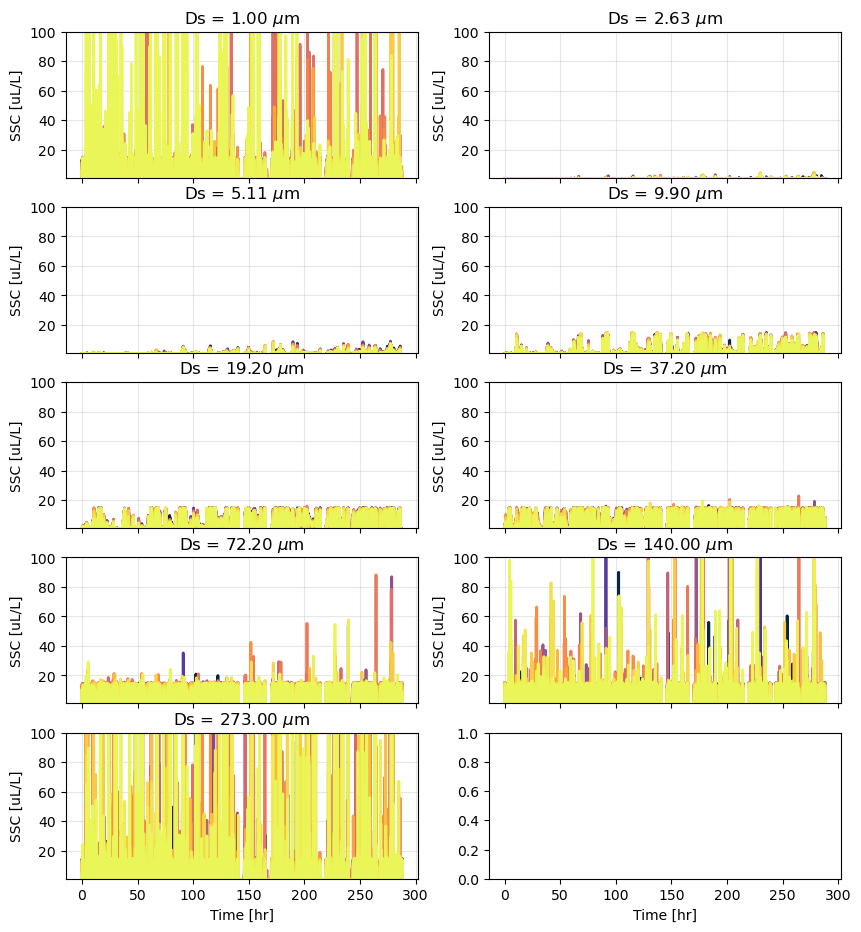

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 11), sharex=True, sharey=False)
axs = axs.flatten()


for j, Ds in enumerate(range(0, Ns, 4)):
    if j > 9:
        continue
    axs[j].grid(alpha=0.3)
    axs[j].set_title(r"Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))
    time = ds.time.values / 3600
    axs[j].set_ylim(1, 100)
    axs[j].set_ylabel("SSC [uL/L]")
    # axs[j].set_yscale('log')
    for i in range(0, Nens):
        # G = ds.G.isel(time=1, N=i)
        s0 = ds.ssc.isel(N=i).isel(Ds=Ds) * volume[Ds] * 1e6
                # s0 = s0.rolling(time=10, center=True).mean().values
        axs[j].plot(time, s0, color=cmo.cm.thermal(i/Nens), linewidth=2) #, label="Nens=%d" % i)
        
# axs[-5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs[-1].set_xlabel("Time [hr]")
axs[-2].set_xlabel("Time [hr]")

# fig.savefig("time_evolution_G=%d.png" % (G), dpi=300, bbox_inches='tight')

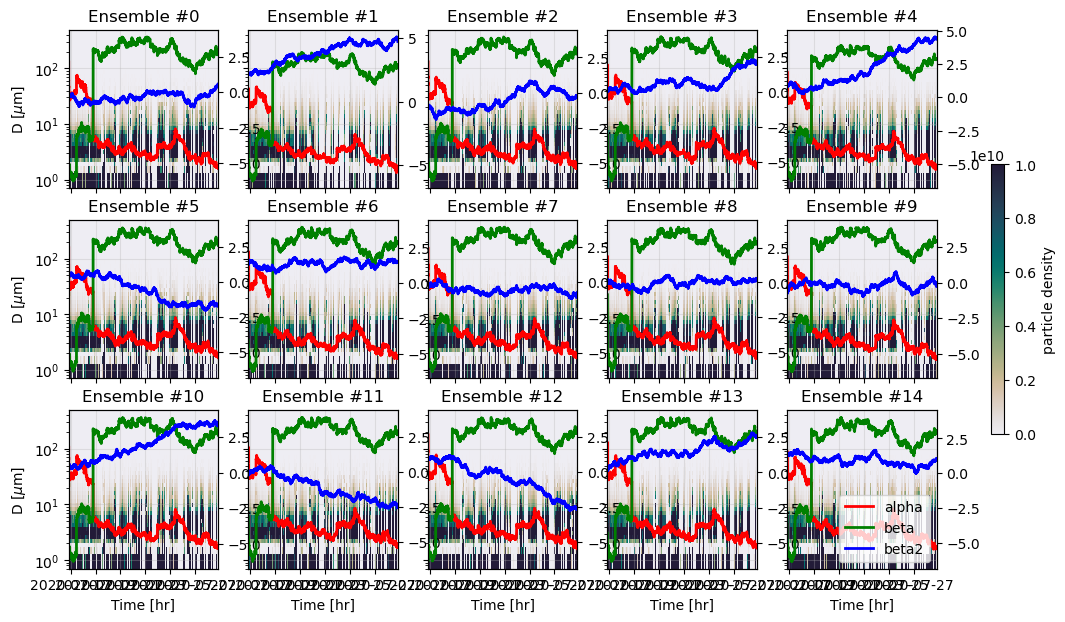

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(14, 7), sharex=True, sharey=True)
axs[0,0].set_ylabel(r"D [$\mu$m]")
axs[1,0].set_ylabel(r"D [$\mu$m]")
axs[2,0].set_ylabel(r"D [$\mu$m]")

for j in range(5):
    axs[2,j].set_xlabel("Time [hr]")
axs = axs.flatten()


for i in range(0, 15):
    axs[i].grid(alpha=0.3)
    axs[i].set_title("Ensemble #%d" % i)
    time = ds.time.values / 3600
    ssc = ds.ssc.isel(N=i) # * volume * 1e6
    # print(ssc.values)
    # assert(False)
    alpha = ds.alpha.isel(N=i)
    beta = ds.beta.isel(N=i)
    beta2 = ds.beta2.isel(N=i)
    ax2 = axs[i].twinx() 
    ax2.plot(mtime, alpha, color = 'r', label="alpha", linewidth=2)
    ax2.plot(mtime, beta, color = 'g', label="beta", linewidth=2)
    ax2.plot(mtime, beta2, color = 'b', label="beta2", linewidth=2)
    # ax2.set_ylim(0, 1)
    h = axs[i].pcolormesh(mtime, ds.Ds.values*1e6, ssc.T, cmap=cmo.cm.rain, shading='auto', vmin=0, vmax=1e10)
    axs[i].set_yscale("log")

plt.colorbar(h, ax=axs, orientation='vertical', label="particle density", shrink=0.5)
ax2.legend() 

# fig.savefig("time-space_G/=%d.png" % (G), dpi=300, bbox_inches='tight')

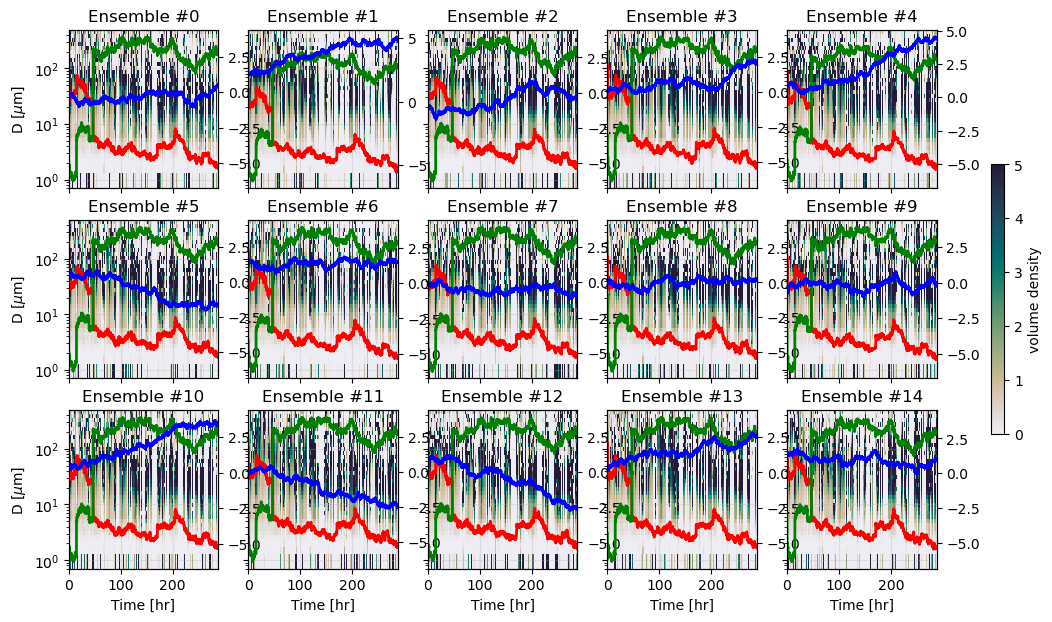

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(14, 7), sharex=True, sharey=True)
axs[0,0].set_ylabel(r"D [$\mu$m]")
axs[1,0].set_ylabel(r"D [$\mu$m]")
axs[2,0].set_ylabel(r"D [$\mu$m]")

for j in range(5):
    axs[2,j].set_xlabel("Time [hr]")
axs = axs.flatten()


for i in range(0, 15):
    axs[i].grid(alpha=0.3)
    axs[i].set_title("Ensemble #%d" % i)
    time = ds.time.values / 3600
    ssc = ds.ssc.isel(N=i) * volume * 1e6
    # print(ssc.values)
    # print(ds.Ds.values*1e6)

    h = axs[i].pcolormesh(time, ds.Ds.values*1e6, ssc.T, cmap=cmo.cm.rain, shading='auto', vmin=0, vmax=5)
    axs[i].set_yscale("log")

    alpha = ds.alpha.isel(N=i)
    beta = ds.beta.isel(N=i)
    beta2 = ds.beta2.isel(N=i)
    ax2 = axs[i].twinx() 
    ax2.plot(time, alpha, color = 'r', label="alpha", linewidth=2)
    ax2.plot(time, beta, color = 'g', label="beta", linewidth=2)
    ax2.plot(time, beta2, color = 'b', label="beta2", linewidth=2)

plt.colorbar(h, ax=axs, orientation='vertical', label="volume density", shrink=0.5)

# fig.savefig("time-space_G=%d.png" % (G), dpi=300, bbox_inches='tight')

In [ ]:
# ### Flux coefficient 
# fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(14, 7), sharex=True, sharey=True)
# axs[0,0].set_ylabel(r"D [$\mu$m]")
# axs[1,0].set_ylabel(r"D [$\mu$m]")
# axs[2,0].set_ylabel(r"D [$\mu$m]")

# for j in range(5):
#     axs[2,j].set_xlabel("Time [hr]")
# axs = axs.flatten()


# for i in range(0, 15):
#     axs[i].grid(alpha=0.3)
#     axs[i].set_title("Ensemble #%d" % i)
#     flux = ds.flux.isel(N=i)
#     flux = np.sin(flux) 
#     h = axs[i].pcolormesh(mtime, [1, 2], flux.T, cmap=cmo.cm.balance, shading='auto', vmin=-1, vmax=1)
#     format_date_ax(axs[i], int=48)
# plt.colorbar(h, ax=axs, orientation='vertical', label="particle density", shrink=0.5)
# plt.suptitle("flux (+/-)")
# # fig.savefig("time-space_G=%d.png" % (G), dpi=300, bbox_inches='tight')

In [ ]:
if 0 :
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(14, 7), sharex=True, sharey=False)

    depths =  np.squeeze(adcp.P_1.values) #+ 0.41
    ax2 = axs[0].twinx()
    ax2.plot(rtime, depths, color='k', label='Depth')

    # interpolate to compare
    U = adcp_u.mean(dim="depth")
    temp = pd.DataFrame({'u': np.squeeze(U.values)})
    temp.index = rtime 
    output = pd.DataFrame(index=mtime)

    combined_index = temp.index.union(output.index)
    adcp_aligned = temp.reindex(combined_index).interpolate(method='time')
    output['u'] = adcp_aligned

    keys = [] 
    colors = [] 

    for i in range(0, 2):
        color = cmo.cm.haline(i/2)
        f0 =ds.flux.isel(Nf=i).mean(dim="N")
        f0 = f0.rolling(time=2).mean()
        f0 = np.sin(f0)
        keys.append(i)
        colors.append(color)
        output[i] = f0.values
        axs[1].plot(output[i], '-', color=color, alpha=0.5, linewidth=3)
        axs[2].plot(output.u/100, '--k')

    axs[0].set_xlim(mtime[0], mtime[-1])


    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3), sharex=True, sharey=False)
    axs = axs.flatten()

    for i,(key,c) in enumerate(zip(keys, colors)):
        if i>11:
            continue
        axs[i].set_title("Ds = %s $\mu$m" % key)
        axs[i].hist(output[key].loc[output.u>0], bins=5, alpha=0.5, label="Flood", color='skyblue', density=True)
        axs[i].hist(output[key].loc[output.u<0], bins=5, alpha=0.5, label="Ebb", color='red', density=True)
        # axs[0].plot(, '.', label=key, color=c, markersize=float(key)/50)
        # axs[0].set_xlabel("Flux")
        # axs[0].set_ylabel("Velocity [m/s]")
        # axs[0].legend()
        axs[i].grid(alpha=0.3)
        axs[i].set_xlim(-0.2, 0.2)
        axs[i].vlines(0, 0, 20, color='k', alpha=0.5, linewidth=1)
    axs[0].legend()


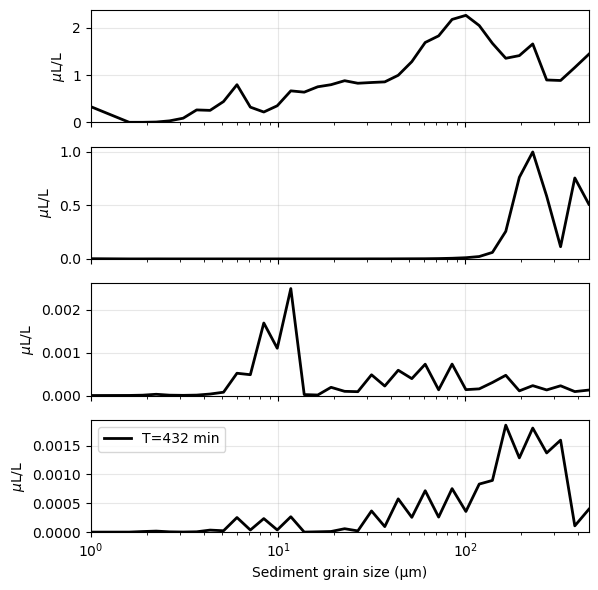

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6, 6), sharex=True, sharey=False)


for it, t in enumerate(range(0, nt, nt//4)):
    if it>3:
        continue 
    Ds = ds.Ds.values*1e6
    label="T=%d min" % (t*10/60)
    # for i in range(0, Nens):
    #     var = ds.ssc.isel(time=t, N=i) * volume.isel(N=i)
    #     axs[it].plot(Ds, var, '-', color=cmo.cm.haline(i/Nens), linewidth=2, alpha=0.1) #,color=cmo.cm.thermal(t/nt))

    mean = ds.ssc.isel(time=t).mean(dim="N")* volume *1e6
    axs[it].plot(Ds, mean, '-', color='k', linewidth=2, label=label)

    axs[it].set_xscale('log')
    axs[it].grid(alpha=0.3)
    axs[it].set_ylabel("$\mu$L/L") #  10$^6$ particles/m$^3$
    axs[it].set_ylim(0,)
    axs[it].set_xlim(Ds[0], Ds[-1])

axs[-1].set_xlabel("Sediment grain size (µm)")
axs[-1].legend()

plt.tight_layout()

# fig.savefig("pdf_G=%d.png" % (G), dpi=300, bbox_inches='tight')

In [ ]:
def weighted_median_axis1(data, weights):
    # Sort the data and weights along axis 1
    sort_idx = np.argsort(data, axis=1)
    sorted_data = np.take_along_axis(data, sort_idx, axis=1)
    sorted_weights = np.take_along_axis(weights, sort_idx, axis=1)
    
    # Compute cumulative sum of weights
    cum_weights = np.cumsum(sorted_weights, axis=1)
    cutoff = np.sum(sorted_weights, axis=1, keepdims=True) / 2.0
    
    # Find the first index where cumulative weight exceeds half the total weight
    idx = np.argmax(cum_weights >= cutoff, axis=1, keepdims=True)
    
    # Extract the median values
    return np.take_along_axis(sorted_data, idx, axis=1).squeeze()



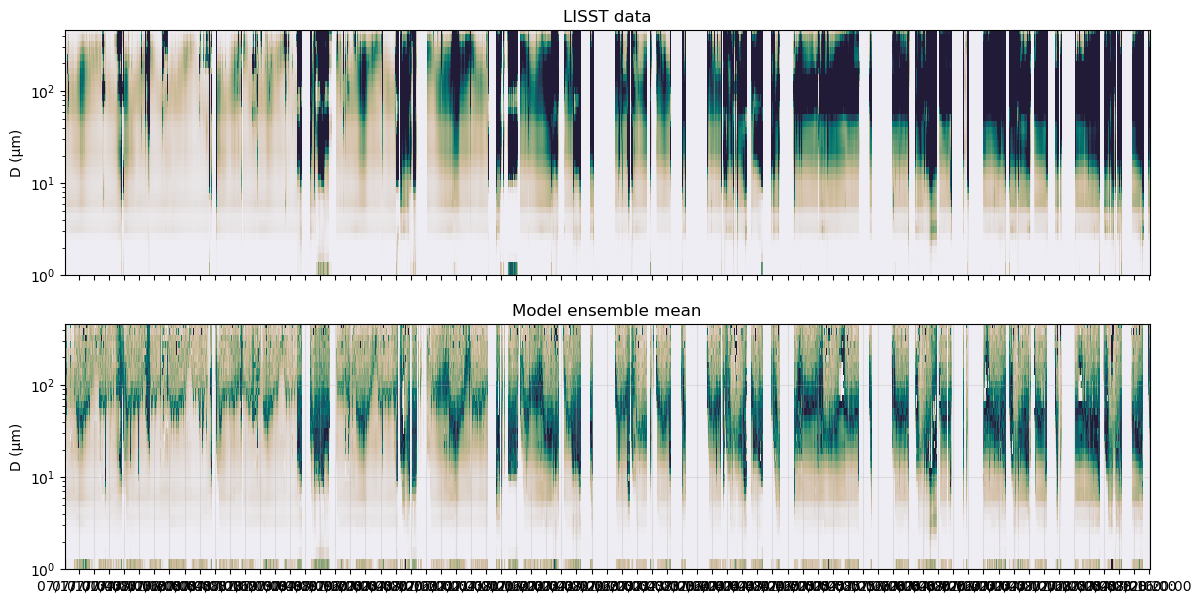

In [ ]:
l_ds = lds.size_class.values
vconc = lds.vconc.mean(dim='sample').isel(depth=0).values
lds_time = lds.time.values

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(14, 7), sharex=True, sharey=True)
axs = axs.flatten()

axs[0].pcolormesh(lds_time, l_ds, vconc.T, cmap=cmo.cm.rain, shading='auto', vmin=0, vmax=10)

ssc = ds.ssc #.where(ds.ssc>0)
ssc0 = ssc.mean(dim="N") * volume * 1e6
axs[0].set_title("LISST data")
axs[1].set_title("Model ensemble mean")

i= 1 
axs[i].grid(alpha=0.3)
h = axs[i].pcolormesh(mtime, ds.Ds.values*1e6, ssc0.T, cmap=cmo.cm.rain, shading='auto', vmin=0, vmax=10)
axs[i].set_yscale("log")
axs[i].set_xlim(mtime[0], mtime [-1])
axs[i].set_ylim(ds.Ds.values[0]*1e6, ds.Ds.values[-1]*1e6)

format_date_ax(axs[i], 4)

for ax in axs:
    ax.set_ylabel("D (µm)")

In [ ]:

# DescrStatsW expects 1D or 2D arrays. We can apply it row-by-row or across the axis.
# If Ds_aligned and weights are 2D arrays:


/global/home/users/siennaw/.conda/envs/geoplot/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


(18459.84028935185, 18471.83681640625)

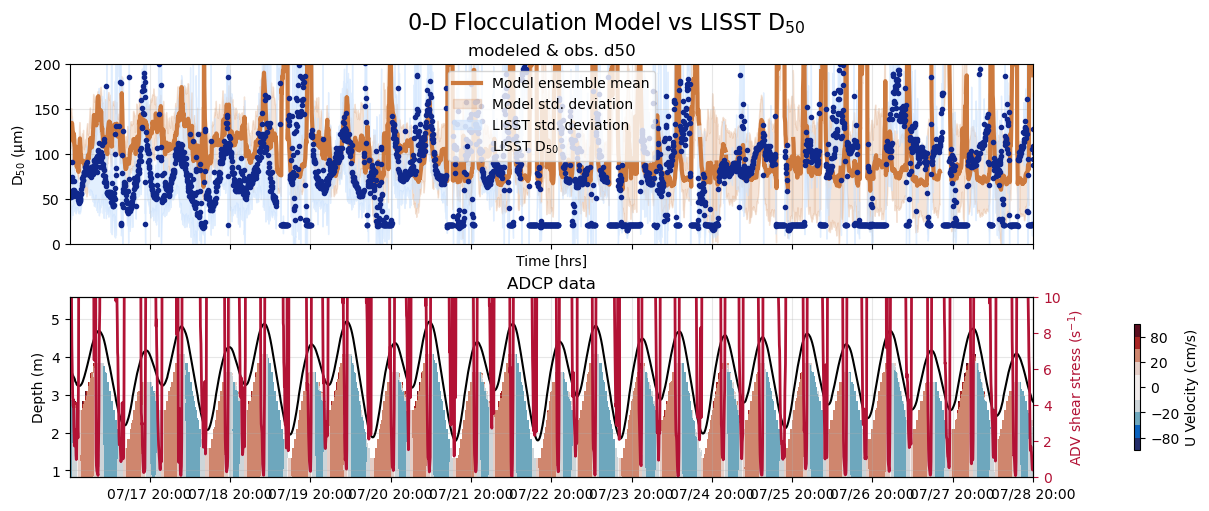

In [ ]:

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 5), sharex=True, sharey=False, constrained_layout=True)

var = ds.ssc.mean(dim='N')
weights = var.values + 1e-9
Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
mean_d = np.average(Ds, axis=1, weights=weights)

################## SHEAR STRESS FROM THE ADV  ##################
shear = ds.G.isel(N=0) 
ax = axs[0]
ax2 = axs[1].twinx()
ax2.plot(mtime, shear, '-', color='#B21235', linewidth=2, label="Shear stress")
ax2.set_ylim(0,10)
ax2.tick_params(axis='y', colors='#B21235')
ax2.set_ylabel("ADV shear stress (s$^{-1}$)", color='#B21235')

# Number of particles 
var = ds.ssc.rolling(time=5).mean() # shape = (1380, 10, 250)
Ds_aligned = ds.Ds.values[None, :, None]

var = xr.where(var < 0, 0, var)
weights = var  *  volume 
# print(lds.size_class.shape)
# print(weights.shape)

mean_d = np.sum(Ds_aligned * weights, axis=1) / np.sum(weights, axis=1) 
std_ = mean_d.std(axis=1)

################## MODELLED D50 ##################
mean_d = np.median(mean_d, axis=1)
ax.plot(mtime, mean_d*1e6, color='#CD7A3E', linewidth=3, label="Model ensemble mean") 
ax.fill_between(mtime, np.squeeze(mean_d-std_)*1e6, np.squeeze(mean_d+std_)*1e6, color="#CD7A3E", alpha=0.2, label="Model std. deviation")
# print(mean_d)
################## FORMAT AXES ##################
ax.grid(alpha=0.3)
ax.set_xlabel("Time [hrs]")
ax.set_ylabel("D$_{50}$ (µm)")
ax.set_ylim(10, 200) 


################## LISST DATA ##################
d50 = lds['D50'].isel(depth=0)
stds = lds['D50'].std(axis=1) 
d50 = lds['D50'].mean(axis=1)

ax.fill_between(ldates, np.squeeze(d50-stds), np.squeeze(d50+stds), color='#CBE2FE', alpha=0.55, label="LISST std. deviation")
ax.plot(ldates, d50, 'o', color='#10288C', label="LISST D$_{50}$", markersize=3)
format_date_ax(ax, 24)
ax.set_ylim(0, 200)

# Add ADCP 
h = axs[1].contourf(rtime, -adcp_z + offset, adcp_u.T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[1].grid(alpha=0.3)
depths =  np.squeeze(adcp.P_1.values) #+ 0.41
axs[1].plot(rtime, depths, color='k', label='Depth')
axs[1].set_ylabel("Depth (m)")
axs[0].legend()


axs[0].set_title("modeled & obs. d50")

axs[1].set_title("ADCP data")

plt.suptitle("0-D Flocculation Model vs LISST D$_{50}$", fontsize=16)
ax.set_xlim(mtime[0], mtime[-1])

# ax.set_yscale('log')
# ax.set_title("Shear = %d s$^{-1}$" % G)

# fig.savefig("validation.png" % (G), dpi=300, bbox_inches='tight')

In [ ]:
# LISST size classes // append last element
def date2color(date, cmap=cmo.cm.haline):
    d0 = pd.to_datetime(ldates[i])
    d0 = mtime[0] #pd.to_datetime(m)
    d1 = (d0 - mtime[-1]).total_seconds() 
    normalize = (d0 - date).total_seconds() / d1
    return cmo.cm.haline(normalize)
x = lds.size_class.values 
x = np.append(x, x[-1])

if 0 : 
    x = lds.size_class.values 
    x = np.append(x, x[-1])

    fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=True)


    Ds_ = ds.Ds.values*1e6        
    with np.errstate(divide='ignore', invalid='ignore'):
        for i in range(5, nt, nt//6):
            conc = ds.ssc.isel(time=i)
            conc = conc*volume
            conc = conc.mean(dim='N').values

            cdf_integrated = cumulative_trapezoid(conc, Ds_, initial=0)
            cdf = cdf_integrated / cdf_integrated[-1]   

            pdf = np.gradient(cdf, Ds_)
            print(np.trapezoid(pdf, Ds_))

            # 4. Plot the CDF against your x-axis (Ds)
            color = date2color(mtime[i]) 
            axs[1].plot(Ds_, pdf, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

            ### Plot equivalent LISST data
            cdf = lds.CDF.sel(time=mtime[i], method='nearest').isel(depth=0)
            cdf = cdf.mean(dim='sample')
            pdf = np.gradient(cdf, x)
            d0 = pd.to_datetime(cdf.time.values)
            color = date2color(d0) 
            axs[0].plot(x, pdf, '-', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

    axs[1].set_title("Floc Model PDF")
    axs[0].set_title("LISST PDF")
    # axs[0].set_ylim(0, 0.05)   

    for ax in axs:
        ax.set_xlim(1, 1000)
        
        ax.set_xlabel('D$_{50}$ ($\mu$m)')
        ax.grid(alpha=0.2)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        ax.set_xscale('log')

In [ ]:
# CDF 

if 0 : 
    fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=False)
        
    for i in range(5, nt, 5):

        conc = ds.ssc.isel(time=i)

        conc = conc*volume/np.sum(volume*conc)
        conc = conc.mean(dim='N').values


        cdf_integrated = cumulative_trapezoid(conc, Ds_, initial=0)
        cdf = cdf_integrated / cdf_integrated[-1]   

        # 4. Plot the CDF against your x-axis (Ds)
        color = date2color(mtime[i]) 
        axs[1].plot(Ds_, cdf, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))
    
        ### Plot equivalent LISST data

        cdf = lds.CDF.sel(time=mtime[i], method='nearest').isel(depth=0)
        cdf = cdf.mean(dim='sample')

        d0 = pd.to_datetime(cdf.time.values)
        color = date2color(d0) 
        axs[0].plot(x, cdf, '-', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

    axs[1].set_title("Floc Model CDF")
    axs[0].set_title("LISST CDF")

    for ax in axs:
        ax.set_xlim(1, 1000)
        
        ax.set_xlabel('D$_{50}$ ($\mu$m)')
        # ax.set_xlim(x[0], x[-1])
        ax.grid(alpha=0.2)
        # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

        ax.set_xscale('log')

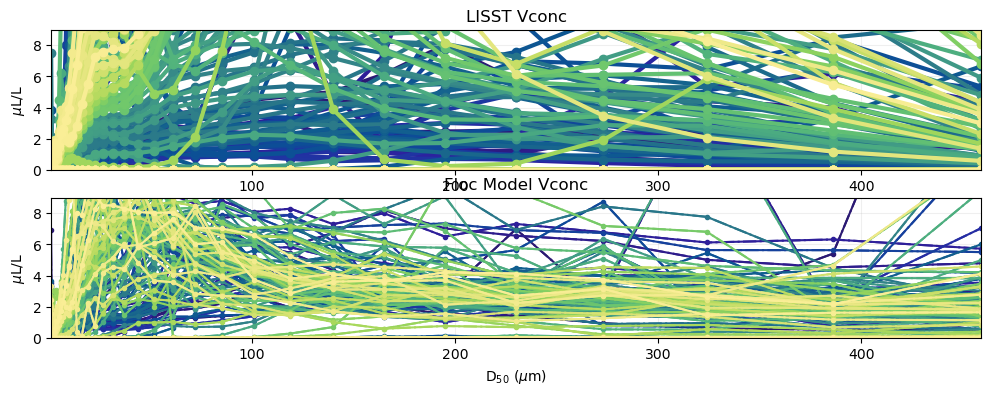

In [ ]:
# volume concentration

fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=True)

Ds = ds.Ds.values*1e6


# H = ds.H.values

# H[H>0] = 1 
# H[H<1] = 0


for i in range(5, nt, 20):
    conc = ds.ssc.isel(time=i)
    
    conc = conc.mean(dim='N').values 
    interpolated = conc * volume * 1e6 #@ ds.H.values 
    # print(interpolated)
    # assert(False)
    # print(interpolated)
    # 4. Plot the CDF against your x-axis (Ds)
    color = date2color(mtime[i]) 
    # interpolated = np.interp(x[0:-1], Ds_, conc) 

    axs[1].plot(Ds, interpolated, '-.', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))
    interpolated = conc @ ds.H.values 
    # print(ds.H.values)
    axs[1].plot(x[0:-1], interpolated, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    # axs[1].plot(Ds_, conc, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    ### Plot equivalent LISST data
    cdf = lds.vconc.sel(time=mtime[i], method='nearest').isel(depth=0)
    cdf = cdf.mean(dim='sample')

    d0 = pd.to_datetime(cdf.time.values)
    color = date2color(d0) 
    axs[0].plot(x[0:-1], cdf, '-o', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model Vconc")
axs[0].set_title("LISST Vconc")

for ax in axs:
    # ax.set_xlim(x[0], x[-1])
    ax.set_ylim(0,9)
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.2)
    # ax.set_xlim(100, 150)
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    # ax.set_xscale('log')
    ax.set_ylabel("$\mu$L/L")
    # print(lds.vconc)

Text(0, 0.5, 'LISST')

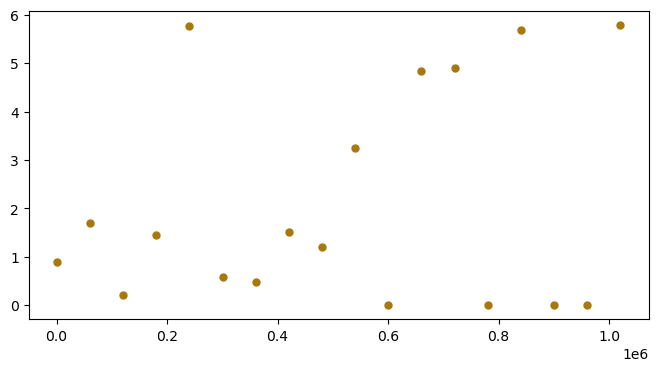

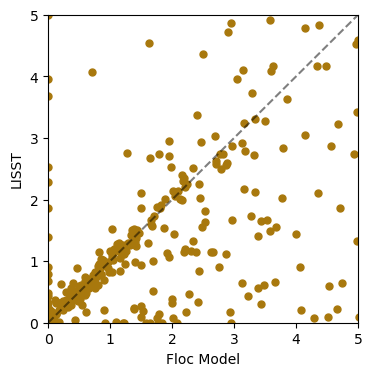

In [ ]:
lstdata= pd.read_csv("lisst_data.csv")

seconds = lstdata['seconds'].values

size_classes = lstdata.columns[1:]


fig2 = plt.figure(figsize=(8, 4))
ax2 = plt.gca()
# i=0
fig = plt.figure(figsize=(4, 4))
ax = plt.gca()

for i in range(0, nt, 200):
    color = cmo.cm.phase(i/10)
    t = seconds[i]
    conc = ds.ssc.sel(time=t, method='nearest')
    conc = conc @ ds.H 
    conc = conc.mean(dim='N') #isel(N=10) # mean(dim='N').values 
    l = lstdata.iloc[i, 1:].values
    ax.plot(conc, l, 'o', color=color, markersize=5, label="t=%d s" % t)
    error = np.mean(np.sqrt((conc - l)**2)) 
    ax2.plot(t, error, 'o', color=color, markersize=5, label="t=%d s" % t)
ax.set_xlim(0, 5)
ax.set_ylim(0,5)
ax.plot([0, 10], [0, 10], '--k', alpha=0.5)
ax.set_xlabel("Floc Model")
ax.set_ylabel("LISST")





# l = lstdata.iloc[0, 1:].values
# # Hi = np.linalg.inv(ds.H.values)
# H = ds.H.values 
# H[H > 0] = 1/H[H > 0]
# # print(H)
# ic = H @ l 
# ic = ic.astype(int)

In [ ]:

# # interpolate LISST data and ACDP data
# df_l = pd.Series(np.squeeze(d50), index=ldates)
# df_v = pd.DataFrame(index=rtime) 
# df_v['velocity'] = adcp_u.mean(dim='depth')

# # Interpolate df_l on df_v index
# df_l_interp = df_l.reindex(df_v.index.union(df_l.index)).interpolate('time').reindex(df_v.index)


# df_v['d50'] = df_l_interp
# df_v.dropna(inplace=True)
# df_v = df_v[df_v['d50'] > 30] # remove negative values

# fig = plt.figure(figsize=(10, 5))
# ax = plt.gca()

# ax.plot(df_v.velocity, df_v.d50, '.', color='#7A3D5D', label="LISST D$_{50}$", alpha=0.2, markersize=15)
# ax.set_yscale('log')
# ax.set_xlabel("Depth-averaged ADCP velocity (cm/s)")
# ax.set_ylabel("D$_{50}$ (µm)")
# ax.grid(alpha=0.3)

# # Histogram for flood and ebb 
# ebb = df_v[df_v.velocity < 0]
# flood = df_v[df_v.velocity > 0]
# fig = plt.figure(figsize=(5, 3))
# ax = plt.gca()
# ax.hist(ebb.d50, bins=80, alpha=0.5, label="Ebb", color='b', density=True)
# ax.hist(flood.d50, bins=80, alpha=0.5, label="Flood", color='r', density=True)
# ax.set_xscale('log')
# ax.set_xlabel("D$_{50}$ (µm)")
# ax.grid(alpha=0.2)
# ax.set_ylabel("Density")
# ax.legend()

alpha: 0.5802558818205619 0.6204246243166777
-3.4712373374127177 0.6204246243166777
-0.06213754930683383 0.9734601369278083
alpha: -3.591469431198452 0.09011984061611619
2.689717985852241 0.09011984061611619
-0.02674148637148386 1.2759446354138562
alpha: -4.311909215628161 0.10406119827862886
3.547154101510106 0.10406119827862886
-0.020913195254030025 1.381584114607933
alpha: -3.398911750949233 0.10146578694990115
2.236181203757563 0.10146578694990115
0.0493951477517415 1.5102828846000207


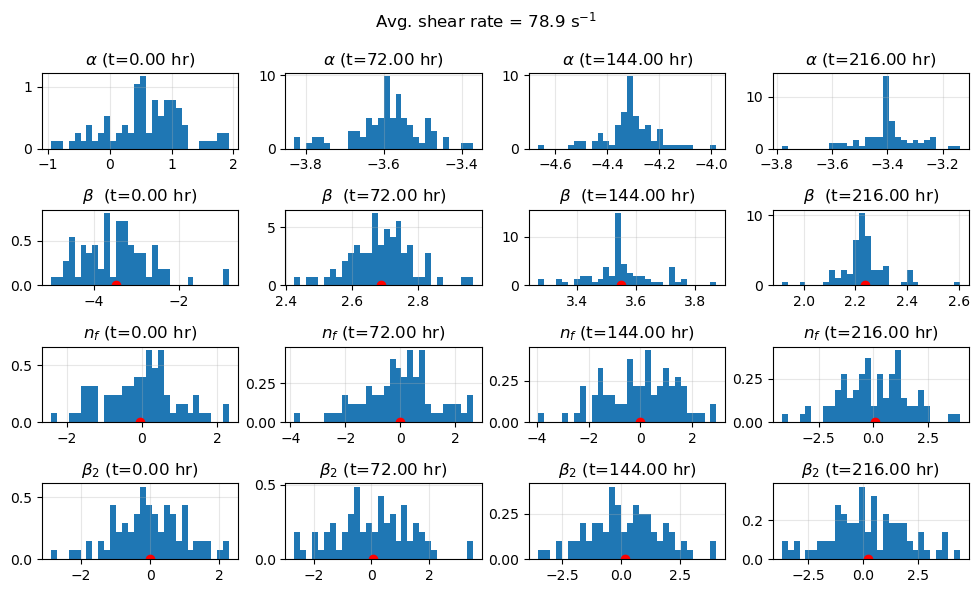

In [ ]:
import numpy as np 

fig, axs = plt.subplots(figsize=(10, 6), nrows=4, ncols=4, sharex=False) #, sharex='row')
shears = ds.G.values.flatten()
shear = np.mean(shears)
plt.suptitle(r"Avg. shear rate = %2.1f s$^{-1}$" % shear) #%.2f hr" % (ds.time.isel(time=i).values/3600))

total = nt
for i, t in enumerate(range(0, total, total//4)):

    if i>3:
        continue
    alphas = ds.alpha.isel(time=t).values
    betas = ds.beta.isel(time=t).values
    nfs = ds.nf.isel(time=t).values
    beta2s = ds.beta2.isel(time=t).values
    axs[0, i].hist(alphas, density=True, bins=30) 
    print("alpha:" ,np.mean(alphas), np.std(alphas))
    print(np.mean(betas), np.std(alphas))
    print(np.mean(nfs), np.std(nfs))


    axs[0, i].set_title(r"$\alpha$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[1, i].hist(betas, density=True, bins=30) 
    axs[1, i].plot(np.mean(betas), 0, 'ro', label="mean")
    axs[1, i].set_title(r"$\beta$  (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))

    axs[2, i].hist(nfs, density=True, bins=30) 
    axs[2, i].set_title("$n_f$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[2, i].plot(np.mean(nfs), 0, 'ro', label="mean")


    axs[3, i].hist(beta2s, density=True, bins=30)
    axs[3, i].set_title(r"$\beta_2$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[3, i].plot(np.mean(beta2s), 0, 'ro', label="mean")

for ax in axs.flatten():
    ax.grid(alpha=0.3)
plt.tight_layout()
    # axs[0].set_yscale('log')
    # axs[1].set_yscale('log')
    # axs[2].set_y

<xarray.DataArray 'nf' (time: 3456, N: 80)> Size: 2MB
array([[2.62504472, 3.00034259, 2.76580808, ..., 2.47640491, 2.18786851,
        3.11946522],
       [2.61573679, 2.99954985, 2.75684148, ..., 2.47823927, 2.17992288,
        3.12157358],
       [2.61177525, 3.00442779, 2.76943476, ..., 2.46866838, 2.18180344,
        3.12773939],
       ...,
       [3.05844068, 2.30260635, 2.18421327, ..., 2.4466115 , 2.06345754,
        2.96991757],
       [3.04710665, 2.30307891, 2.18300889, ..., 2.4448371 , 2.06495483,
        2.97037468],
       [3.05669484, 2.30475149, 2.1881826 , ..., 2.43736064, 2.06669774,
        2.95986252]])
Coordinates:
  * time     (time) float32 14kB 0.0 300.0 600.0 ... 1.036e+06 1.036e+06
Dimensions without coordinates: N


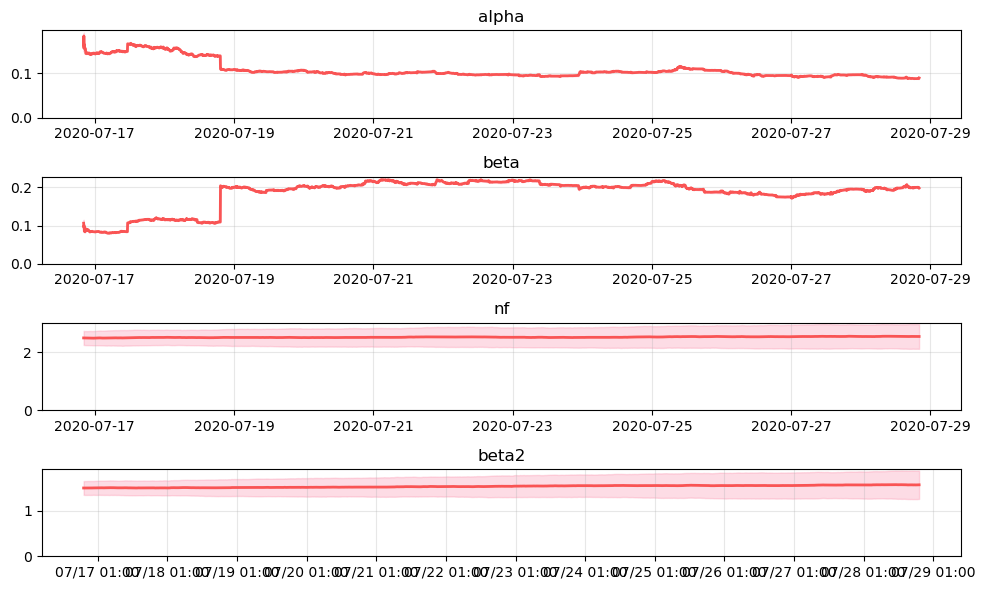

In [ ]:
fig, axs = plt.subplots(figsize=(10, 6), nrows=4, ncols=1, sharex=False)

alpha0 = 0.15
beta0  = 0.15 
nf0 = 2.5 # change?  
beta20 = 1.5

alpha = alpha0 * np.exp(0.1*ds['alpha']) 
beta = beta0 * np.exp(0.1*ds['beta']) 
beta2 = beta20 * np.exp(0.1*ds['beta2']) 
nf = nf0 * np.exp(0.1*ds['nf']) 
print(nf)

dictionary = {'alpha': alpha, 'beta': beta, 'nf': nf, 'beta2': beta2}
for iv, variable in enumerate(['alpha', 'beta', 'nf', 'beta2']):
    var = dictionary[variable]
    mean_var =var.mean(dim='N').values
    std_var = var.std(dim='N').values
    axs[iv].plot(mtime, mean_var, color="#F95454", linewidth=2, label="Mean %s" % variable)
    axs[iv].fill_between(mtime, np.squeeze(mean_var-std_var), np.squeeze(mean_var+std_var), color="#F9547F", alpha=0.2, label="Std. deviation")
    axs[iv].set_title(variable)
    axs[iv].grid(alpha=0.3)
    axs[iv].set_ylim(0,)

# axs[0].set_ylim(0, 0.004)
# axs[1].set_ylim(0, 0.004)
# axs[2].set_ylim(1, 3)
# axs[3].set_ylim(1, 3)
format_date_ax(axs[-1], 24)
plt.tight_layout()